# price and direction prediction

In [1]:
from pickletools import optimize
import os

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../data/aapl.us.csv')
data['Date'] = pd.to_datetime(data['Date'])
data = data.set_index('Date')
# for now, we shall operate on a small subset
data = data.tail(1000)
print(data.index.min(), data.index.max())

2013-11-22 00:00:00 2017-11-10 00:00:00


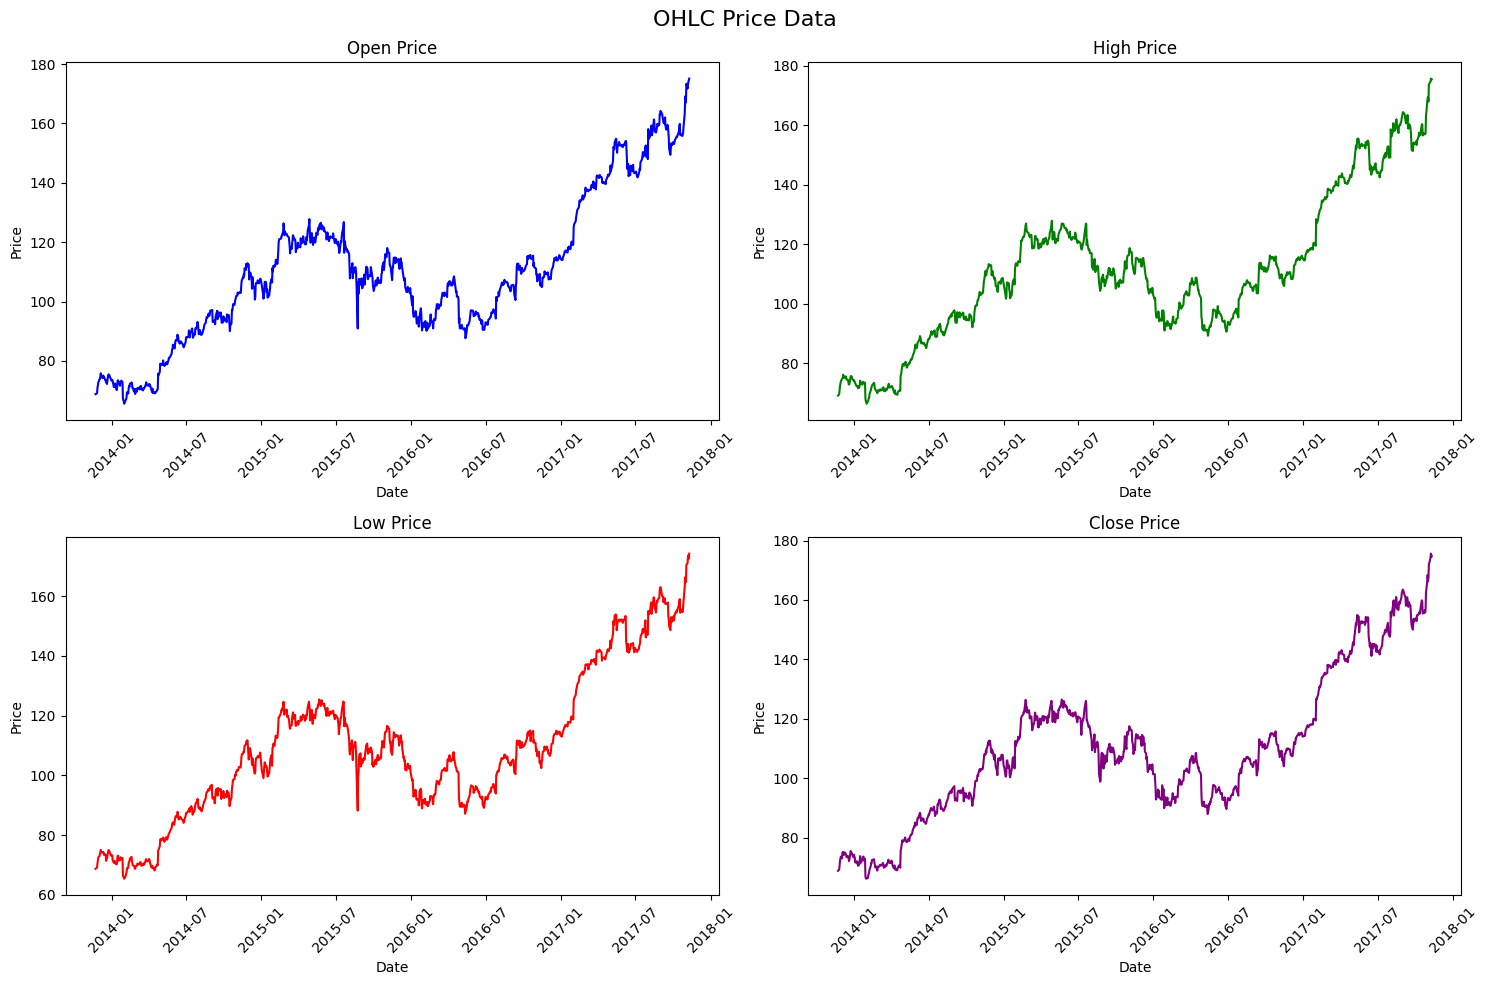

In [3]:
# Plot OHLC values
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('OHLC Price Data', fontsize=16)

axes[0, 0].plot(data.index, data['Open'], color='blue')
axes[0, 0].set_title('Open Price')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price')
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].plot(data.index, data['High'], color='green')
axes[0, 1].set_title('High Price')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Price')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].plot(data.index, data['Low'], color='red')
axes[1, 0].set_title('Low Price')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Price')
axes[1, 0].tick_params(axis='x', rotation=45)

axes[1, 1].plot(data.index, data['Close'], color='purple')
axes[1, 1].set_title('Close Price')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Price')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [4]:
# Create direction label: 1=up, 0=down (using Close)
future_return = data['Close'].pct_change(periods=1).shift(-1)
threshold = 0.002  # 0.2% threshold
data['direction'] = np.where(future_return > threshold, 1, 0)  # up=1, down=0

In [20]:
# feature recognition and normalization
features = ['Open', 'High', 'Low', 'Close']
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[features])

In [21]:
scaled_data # normalized values

array([[0.02935617, 0.02501259, 0.03038512, 0.02424713],
       [0.03115498, 0.02953702, 0.03336945, 0.0289814 ],
       [0.03485304, 0.04199295, 0.0370333 , 0.04067084],
       ...,
       [0.99013852, 1.        , 0.99485776, 1.        ],
       [0.99424747, 0.99862618, 0.98393051, 0.99670977],
       [1.        , 0.99789348, 1.        , 0.99140886]], shape=(1000, 4))

In [6]:
# Use direction as target
sequence_length = 60
X, y = [], []
for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(data['direction'].iloc[i])  # direction label

In [7]:
# Split data: 70% train, 15% validation, 15% test
train_split = int(0.7 * len(X))
val_split = int(0.85 * len(X))

X_train = np.array(X[:train_split])
y_train = np.array(y[:train_split]).astype(int)

X_val = np.array(X[train_split:val_split])
y_val = np.array(y[train_split:val_split]).astype(int)

X_test = np.array(X[val_split:])
y_test = np.array(y[val_split:]).astype(int)

print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")

Train size: 658, Val size: 141, Test size: 141


In [8]:
# convert to pytorch tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.LongTensor(y_train)  # for classification

X_val = torch.FloatTensor(X_val)
y_val = torch.LongTensor(y_val)

X_test = torch.FloatTensor(X_test)
y_test = torch.LongTensor(y_test)

In [9]:
# custom dataset
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [10]:
train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset = TimeSeriesDataset(X_val, y_val)
test_dataset = TimeSeriesDataset(X_test, y_test)

In [11]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [12]:
# define simple lstm model
class LSTMModel(nn.Module):
    def __init__(self, input_size=4, hidden_size=100, num_layers=1, output_size=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        # pytorch lstm (https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0,
                           bidirectional=True)
        ## our fully connected linear layer
        self.fc = nn.Linear(hidden_size * 2, output_size)  # 2 classes

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

In [13]:
model = LSTMModel()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                        factor=0.5, patience=5)

In [14]:
# evaluation function
def evaluate_model(model, data_loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            output = model(batch_X)
            loss = criterion(output, batch_y)
            total_loss += loss.item()
            preds = torch.argmax(output, dim=1)
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)
    model.train()
    return total_loss / len(data_loader), correct / total

In [15]:
# training the model
epochs = 50
model.train()
best_loss = float('inf')
patience = 10
counter = 0

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

for epoch in range(epochs):
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()

    val_loss, val_acc = evaluate_model(model, val_loader, criterion)
    scheduler.step(val_loss)

    # Early stopping logic
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), '../models/best_model.pth')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2%}')

# Load best model
model.load_state_dict(torch.load('../models/best_model.pth'))

# Evaluate on test set
test_loss, test_acc = evaluate_model(model, test_loader, criterion)
print(f'\nFinal Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2%}')

Epoch [10/50], Train Loss: 0.9414, Val Loss: 1.1887, Val Acc: 41.84%
Early stopping at epoch 12

Final Test Loss: 0.9858, Test Accuracy: 49.65%


In [16]:
# Predict on test set
model.eval()
all_preds = []
all_true = []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        logits = model(batch_X)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(batch_y.cpu().numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report:")
print(classification_report(all_true, all_preds, target_names=['Down', 'Up']))

print("Confusion Matrix:")
print(confusion_matrix(all_true, all_preds))


Classification Report:
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00        52
     Neutral       0.00      0.00      0.00        19
          Up       0.50      1.00      0.66        70

    accuracy                           0.50       141
   macro avg       0.17      0.33      0.22       141
weighted avg       0.25      0.50      0.33       141

Confusion Matrix:
[[ 0  0 52]
 [ 0  0 19]
 [ 0  0 70]]


C:\Users\fayaq\PycharmProjects\trading_thing\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\fayaq\PycharmProjects\trading_thing\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\fayaq\PycharmProjects\trading_thing\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

In [18]:
# Direction accuracy (already reported as test_acc)
print(f"Direction Accuracy: {test_acc:.2%}")

Direction Accuracy: 49.65%
